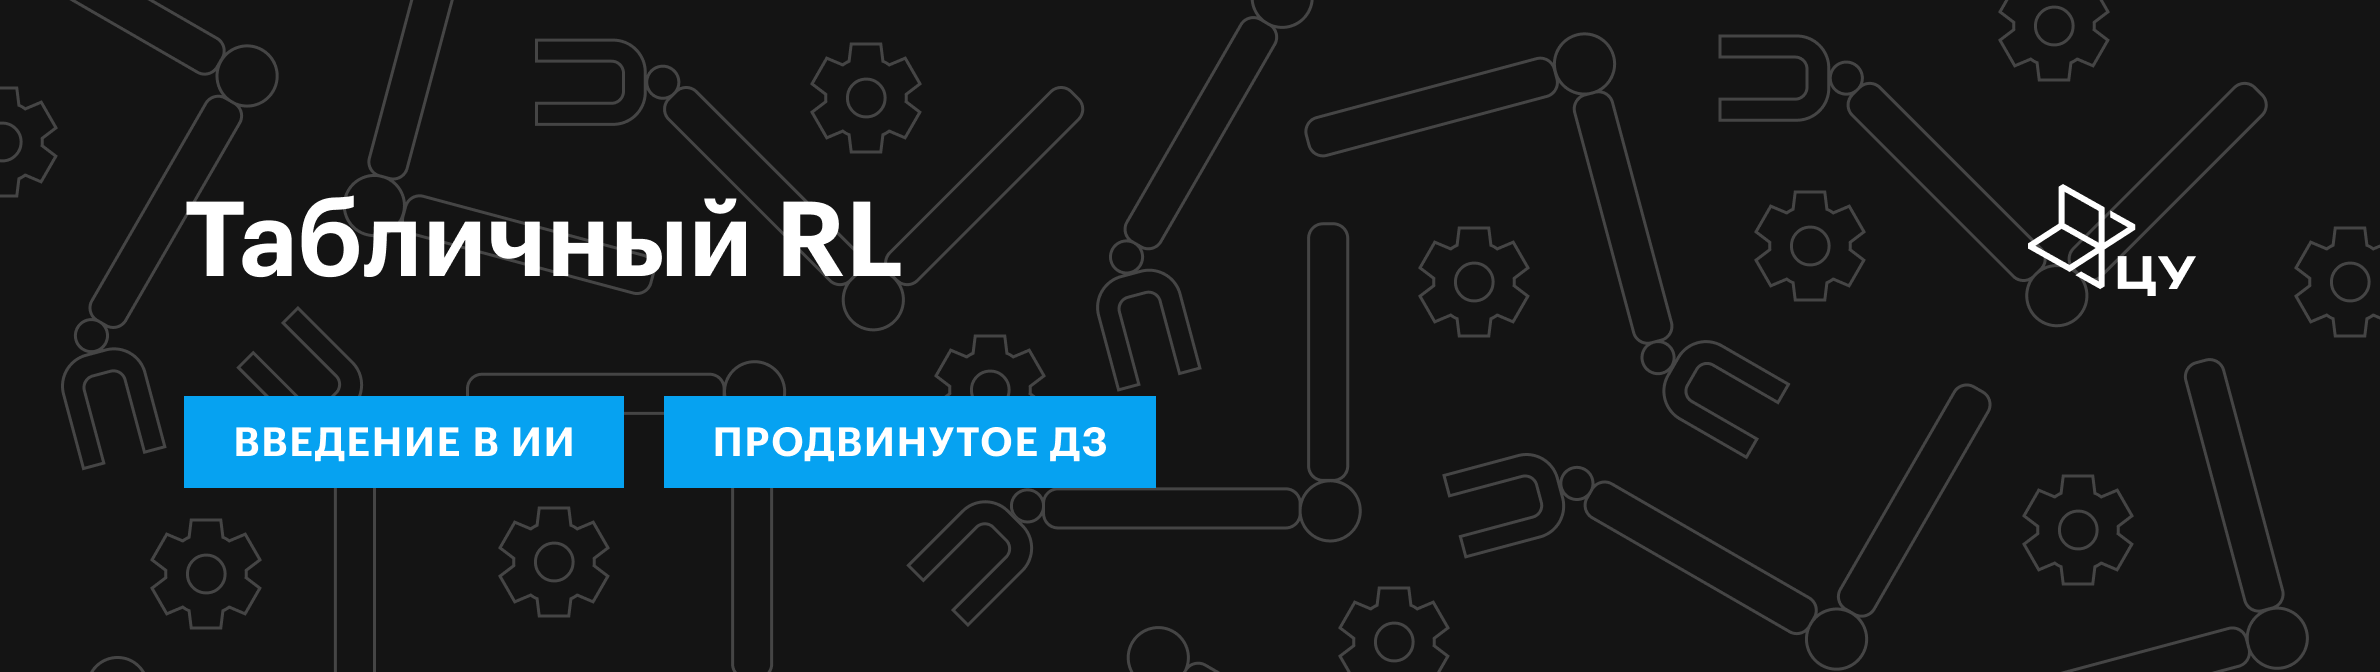

# Домашнее задание по теме «Табличный RL»


В этом задании продолжаем тему продвинутого семинара. На нём мы разобрали четыре алгоритма и обсудили математический аппарат, который лежит в их основе: сжимающие операторы, метод простой итерации, теорему Банаха и другие идеи.

Теперь тебе предстоит реализовать алгоритмы **Policy Iteration** и **Generalized Policy Iteration** и сравнить их между собой.


> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием `# Напиши код здесь`.
>
> 4. После каждого задания старайся коротко интерпретировать результат, а не только получать числа.
>
> 5. Все ячейки должны запускаться последовательно сверху вниз. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.

In [ ]:
# Все необходимые импорты

import gymnasium as gym
import numpy as np

Ты применишь алгоритмы на двух разных средах – FrozenLake-v1 и Taxi-v3.

- **FrozenLake-v1** — это gridworld-среда в виде сетки клеток («озеро»). Агент стартует в клетке S и должен дойти до G, не попав в H (дыры). Клетки F — безопасный лёд. Эпизод заканчивается, когда агент достигает цели, проваливается в дыру или исчерпывает лимит шагов.

    4 возможных действия движения: влево, вправо, вверх, вниз.

    >**Важно.** FrozenLake-v1 допускает стохастику. При создании среды необходимо прописать аргумент `is_slippery = True`. В этом режиме действие будет стохастическим — агент не всегда движется в выбранном направлении (может поскользнуться и пойти в перпендикулярные направления).
    >
    >**Реализовывать алгоритмы на этой среде нужно только в её стохастическом режиме.**

- **Taxi-v3** — это дискретная среда. В ней такси должно доехать до пассажира, который находится в одной из четырёх точек — R, G, Y или B, — забрать его, доехать до точки назначения (те же R, G, Y, B) и высадить. По сравнению с FrozenLake здесь заметно больше состояний.

  Доступны действия:
  - поехать вниз (down),
  - поехать вверх (up),
  - поехать вправо (right),
  - поехать влево (left),
  - подобрать пассажира,
  - высадить пассажира.
  
  Всего есть 500 состояний среды:
  - 25 позиций такси в таблице $5 × 5$,
  - 5 вариантов положения пассажира (4 точки + «в такси»),
  - 4 варианта пункта назначения.
  
  Итого: 25 * 5 * 4 = 500 вариантов.
  
  Состояние среды можно понимать как кортеж вида: `(taxi_row,taxi_column,passenger_location,destination)`.

## Задание 1 [4 балла]

Реализуй алгоритм **Policy Iteration** для сред FrozenLake-v1 и Taxi-v3.

1. Запусти Policy Iteration на Taxi-v3 **[1 балл]**.
2. Запусти Policy Iteration на FrozenLake-v1 **[1 балл]**.
3. Реализуй шаг Policy Evaluation **[1 балл]**.
4. Реализуй шаг Policy Improvement и критерий остановки по стабилизации политики **[1 балл]**.

Используй модель переходов `env.unwrapped.P` для обращения к структуре MDP.

In [ ]:
# Создаём FrozenLake
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

# Создаём Taxi
env_tx = gym.make("Taxi-v4")

# reset/step (обычный запуск эпизода)
obs, info = env_fl.reset()
action = env_fl.action_space.sample()
next_obs, reward, terminated, truncated, info = env_fl.step(action)

# Доступ к модели переходов MDP
P_fl = env_fl.unwrapped.P
P_tx = env_tx.unwrapped.P

print(env_fl.observation_space.n, env_fl.action_space.n)  # nS, nA
print(env_tx.observation_space.n, env_tx.action_space.n)  # nS, nA

# Формат таблицы:
# P[s][a] -> list of transitions
# transition: (prob, next_state, reward, terminated)
print(P_fl[0][2])  # Например: из состояния 0, действие RIGHT


16 4
500 6
[(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]


Воспользуйся скелетом реализации.

In [ ]:
def get_mdp_from_env(env):
    """
    Возвращает:
      P: dict, где P[s][a] = список переходов (prob, s_next, reward, terminated)
      nS: int, число состояний
      nA: int, число действий
    """
    # Напиши код здесь:
    # 1) Достань env.unwrapped.P
    # 2) Достань число состояний и действий из observation_space / action_space
    # 3) Верни P, nS, nA

    # Полезные проверки:
    assert hasattr(env, "unwrapped"), "у env должен быть атрибут unwrapped"
    assert hasattr(env.unwrapped, "P"), "у env.unwrapped должна быть модель переходов P"
    assert hasattr(env, "observation_space") and hasattr(env.observation_space, "n")
    assert hasattr(env, "action_space") and hasattr(env.action_space, "n")

    return env.unwrapped.P, env.observation_space.n, env.action_space.n



In [ ]:
def print_env_summary(env, name="env"):
    """
    Печатает краткую информацию о среде:
    - nS, nA
    - пример переходов из состояния 0 для всех действий
    """
    # Напиши код здесь:
    # 1) Получи P, nS, nA через get_mdp_from_env
    # 2) Распечатай nS и nA
    # 3) Для состояния 0 выведи P[0][a] для всех действий a

    # Полезные проверки:
    assert isinstance(name, str)

    P, nS, nA = get_mdp_from_env(env)
    print(nS, nA)
    print(P[0])

In [ ]:
def init_policy(nS, nA, seed=0):
    """
    Создаёт начальную политику pi[s, a], где сумма по a равна 1

    Возвращает:
      pi: np.ndarray shape (nS, nA)
    """
    # Напиши код здесь:
    # 1) Инициализируй политику shape = (nS, nA)
    # 2) Сделай так, чтобы в каждой строке была корректная вероятность по действиям
    # 3) Верни pi

    # Полезные проверки:
    assert nS > 0 and nA > 0, "nS и nA должны быть положительными"

    shape = (nS, nA)

    pi = np.random.random(size=shape)
    pi[:, 3] = 2
    row_sums = np.sum(pi, axis=1, keepdims=True)
    pi = pi / row_sums

    return pi

In [ ]:
init_policy(16, 4)

array([[0.19760516, 0.13575426, 0.1752179 , 0.49142269],
       [0.18902166, 0.12519863, 0.02765436, 0.65812535],
       [0.06027089, 0.24916742, 0.08908109, 0.6014806 ],
       [0.0340327 , 0.02171122, 0.10006911, 0.84418697],
       [0.11115514, 0.19384315, 0.11928748, 0.57571424],
       [0.17568203, 0.13458028, 0.19448112, 0.49525658],
       [0.01397722, 0.29333813, 0.08283201, 0.60985265],
       [0.12236279, 0.00610408, 0.25845875, 0.61307439],
       [0.21556928, 0.15571164, 0.08643425, 0.54228483],
       [0.21880992, 0.21564052, 0.03281611, 0.53273346],
       [0.24087833, 0.20942512, 0.0554024 , 0.49429415],
       [0.22337618, 0.10500619, 0.13139674, 0.54022088],
       [0.0517987 , 0.24381835, 0.10433433, 0.60004863],
       [0.07579831, 0.09607137, 0.16114082, 0.6669895 ],
       [0.17243905, 0.22866747, 0.07597016, 0.52292332],
       [0.21192457, 0.03287687, 0.18763221, 0.56756636]])

In [ ]:
def policy_to_actions(pi):
    """
    Преобразует политику pi в массив действий actions[s] = argmax_a pi[s, a]

    Возвращает:
      actions: np.ndarray shape (nS,)
    """
    # Напиши код здесь:
    # 1) Для каждого состояния возьми argmax по действиям
    # 2) Верни массив действий

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert np.allclose(pi.sum(axis=1), 1.0), "строки политики должны суммироваться к 1"

    return np.argmax(pi, axis=1)

    # raise NotImplementedError

In [ ]:
policy_to_actions(init_policy(16,4))

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])


### Реализация Policy Evaluation

In [ ]:
def policy_evaluation(P, pi, gamma=0.9, theta=1e-5, max_iters=50):
    """
    Итеративная оценка политики V^pi

    Нужно реализовать обновление Беллмана

    Важно:
      - если переход ведёт в terminal (terminated = True), то будущая ценность НЕ добавляется

    Возвращает:
      V: np.ndarray shape (nS,)
      eval_iters: int (сколько итераций потребовалось)
    """
    # Напиши код здесь:
    # 1) Определи nS и nA по P / pi
    # 2) Инициализировать V нулями
    # 3) Цикл по итерациям:
    #    - для каждого состояния посчитай новое значение
    #    - посчитай delta = max|V_new - V|
    #    - обнови V
    #    - остановись при delta < theta
    # 4) Верни V и число итераций

    # Полезные проверки:
    assert isinstance(P, dict), "P должна быть словарем"
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert np.allclose(pi.sum(axis=1), 1.0), "строки политики должны суммироваться к 1"

    nS, nA = pi.shape
    V = np.zeros((nS))
    for i in range(max_iters):
        V_new = np.zeros((nS))
        for s in range(nS):
            for a in range(nA):
                val = 0
                for prob, s_next, reward, terminated in P[s][a]:
                    if terminated:
                        val += prob * reward
                    else:
                        val += prob * (reward + gamma * V[s_next])
                V_new[s] += pi[s][a] * val
        delta = np.max(np.abs(V - V_new))
        V = V_new
        if delta < theta:
            break
    return V, i + 1

In [ ]:
P, nS, nA = get_mdp_from_env(env_fl)
V, iters = policy_evaluation(P, init_policy(nS, nA))

In [ ]:
def state_action_value(P, V, s, a, gamma=0.9):
    """
    Вычисляет Q(s,a) по известной V

    С учётом terminal:
      если terminated=True, то добавляем только reward (без gamma*V)

    Возвращает:
      q: float
    """
    # Напиши код здесь:
    # 1) Пройди по всем переходам в P[s][a]
    # 2) Если переход терминальный -> добавь только prob * reward
    # 3) Иначе добавь prob * (reward + gamma * V[s_next])
    # 4) Верни q

    # Полезные проверки:
    assert isinstance(P, dict), "P должна быть словарем"
    assert V.ndim == 1, "V должна быть одномерным массивом"
    assert s in P, "состояние s должно быть в P"
    assert a in P[s], "действие a должно быть в P[s]"

    q = 0
    for prob, s_next, reward, terminated in P[s][a]:
        if terminated:
            q += prob * reward
        else:
            q += prob * (reward + gamma * V[s_next])
    return q




### Реализация Policy Improvement

In [ ]:
def policy_improvement(P, V, nA, gamma=0.9):
    """
    Выполняет шаг Policy Improvement

    Возвращает:
      pi_new: np.ndarray shape (nS, nA)
      actions: np.ndarray shape (nS,) (опционально)
    """
    # Напиши код здесь:
    # 1) Для каждого состояния посчитай Q(s,a) для всех действий
    # 2) Выбери лучшее действие
    # 3) Построй новую политику pi_new
    # 4) Верни pi_new и actions

    # Полезные проверки:
    assert isinstance(P, dict), "P должна быть словарем"
    assert V.ndim == 1, "V должна быть одномерным массивом"
    nS = V.shape[0]
    pi_new = np.zeros((nS, nA))
    actions = np.zeros(nS, dtype=int)

    for s in range(nS):
        q = np.zeros(nA)

        for a in range(nA):
            q[a] = state_action_value(P, V, s, a, gamma)

        best_action = np.argmax(q)
        actions[s] = best_action
        pi_new[s, best_action] = 1.0

    return pi_new, actions

In [ ]:
policy_improvement(P, V, nA)

(array([[1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.]]),
 array([0, 3, 0, 3, 0, 0, 0, 0, 3, 1, 0, 0, 0, 2, 1, 0]))

In [ ]:
def policies_equal(pi1, pi2):
    """
    Проверка, что политики одинаковые (критерий остановки)

    Подсказка:
      - сравнить actions = argmax по строкам
      - или np.allclose(pi1, pi2)

    Возвращает:
      bool
    """
    # Напиши код здесь:
    # 1) Сравни две политики удобным способом
    # 2) Верни bool

    # Полезные проверки:
    assert pi1.shape == pi2.shape, "у политик должны совпадать shape"

    return np.allclose(pi1, pi2)

In [ ]:
def policy_iteration(env, gamma=0.9, theta=1e-5, max_eval_iters=500, max_pi_iters=50, seed=0):
    """
    Полный алгоритм Policy Iteration

    Шаги:
      1) получить P, nS, nA
      2) инициализировать pi = init_policy(...)
      3) for k in range(max_pi_iters):
            V, _ = policy_evaluation(...)
            pi_new, _ = policy_improvement(...)
            если политика не изменилась – остановиться
            иначе pi = pi_new

    Возвращает:
      pi, V, info (например: количество итераций политики и т.п.)
    """
    # Напиши код здесь:
    # 1) Получи P, nS, nA
    # 2) Инициализируй политику
    # 3) Запусти цикл policy iteration
    # 4) Если политика перестала меняться — остановись
    # 5) Верни pi, V, info

    # Полезные проверки:
    assert max_eval_iters > 0, "max_eval_iters должно быть положительным"
    assert max_pi_iters > 0, "max_pi_iters должно быть положительным"

    P, nS, nA = get_mdp_from_env(env)
    pi = init_policy(nS, nA)
    for i in range(max_pi_iters):
      V, _ = policy_evaluation(P, pi, gamma, theta, max_eval_iters)
      pi_new, _ = policy_improvement(P, V, nA, gamma)
      if policies_equal(pi, pi_new):
        break
      pi = pi_new
    V, _ = policy_evaluation(P, pi, gamma, theta, max_eval_iters)
    return pi, V, i


In [ ]:
def select_action(pi, s, rng=None):
    """
    Выбирает действие по политике pi в состоянии s

    Вариант 1 (детерминированно):
      a = argmax_a pi[s,a]

    Вариант 2 (стохастически, "как задана pi"):
      a ~ Categorical(pi[s])

    Возвращает:
      int action
    """
    # Напиши код здесь:
    # 1) Выбери один вариант: детерминированный или стохастический
    # 2) Верни действие для состояния s

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert 0 <= s < pi.shape[0], "некорректный индекс состояния s"
    assert np.allclose(pi.sum(axis=1), 1.0), "строки политики должны суммироваться к 1"

    return pi[s].argmax()

In [ ]:
def run_episode(env, pi, seed=None, max_steps=50):
    """
    Запускает 1 эпизод в среде, следуя политике pi

    Возвращает:
      total_reward: суммарная награда
      steps: число шагов
      terminated: bool
      truncated: bool
    """
    # Напиши код здесь:
    # 1) reset(seed)
    # 2) Цикл step:
    #    - выбери action (select_action)
    #    - env.step(action)
    #    - накопи reward
    #    - остановись при terminated or truncated
    # 3) Верни total_reward, steps, terminated, truncated

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert max_steps > 0, "max_steps должно быть положительным"

    s, _ = env.reset()
    total_reward = 0
    for i in range(max_steps):
        action = select_action(pi, s, seed)
        obs, reward, terminated, truncated, info = env.step(action)
        s = obs
        done = terminated or truncated
        total_reward += reward
        if done:
          break
    return total_reward, i, terminated, truncated

In [ ]:
def evaluate_policy(env, pi, n_episodes=50, seed=0):
    """
    Оценивает политику по симуляции

    Возвращает:
      mean_return, std_return
    """
    # Напиши код здесь:
    # 1) Много раз вызови run_episode(...)
    # 2) Собери total_reward
    # 3) Посчитай среднее и std
    # 4) Верни mean_return, std_return

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"

    returns = []
    for i in range(n_episodes):
      total_reward, steps, terminated, truncated = run_episode(env, pi)
      returns.append(total_reward)
    return np.mean(returns), np.std(returns)


### Запуск алгоритма

После того как закончишь реализацию, запусти её, используя код ниже.

Запуск на Taxi-v3.

In [ ]:
env_tx = gym.make("Taxi-v4")

pi_tx, V_tx, info_tx = policy_iteration(env_tx, gamma = 0.9, theta = 1e-5, seed = 0)
mean_G, std_G = evaluate_policy(env_tx, pi_tx, n_episodes = 50, seed = 0)
print("Taxi:", info_tx, "return:", mean_G, "+/-", std_G)

Taxi: 14 return: 7.76 +/- 2.5184121981915513


Запуск на FrozenLake-v1.

In [ ]:
env_fl = gym.make("FrozenLake-v1", map_name = "4x4", is_slippery=False)

pi_fl, V_fl, info_fl = policy_iteration(env_fl, gamma = 0.9, theta = 1e-5, seed = 0)
mean_G, std_G = evaluate_policy(env_fl, pi_fl, n_episodes = 50, seed = 0)
print("FrozenLake:", info_fl, "return:", mean_G, "+/-", std_G)

FrozenLake: 1 return: 1.0 +/- 0.0


## Задание 2 [5 баллов]

Реализуй алгоритм **Generalized Policy Iteration** (GPI)  для сред FrozenLake-v1 и Taxi-v3.

1. Запусти Generalized Policy Iteration на Taxi-v3 **[1 балл]**.
2. Запусти Generalized Policy Iteration на  FrozenLake-v1 **[1 балл]**.
3. Реализуй частичную Policy Evaluation внутри GPI **[1 балл]**.
4. Реализуй Policy Improvement внутри GPI **[1 балл]**.
5. Реализуй полный цикл GPI **[1 балл]**.

Используй модель переходов `env.unwrapped.P` для обращения к структуре MDP.






### Реализация частичной Policy Evaluation

In [ ]:
def policy_evaluation_partial(P, pi, V, gamma=0.99, n_sweeps=1):
    """
    Выполняет НЕ полную оценку политики, а частичную:
    делает ровно n_sweeps обновлений V по Беллману для фиксированной pi

    Вход:
      P: модель переходов
      pi: текущая политика
      V: текущая оценка функции ценности (будет улучшаться)
      gamma: дисконтирование
      n_sweeps: сколько проходов по всем состояниям сделать

    Выход:
      V: обновлённая функция ценности (можно вернуть новый массив или обновить inplace)


    """
    # Напиши код здесь:
    # 1. Определи число состояний nS и число действий nA
    # 2. Выполни ровно n_sweeps полных проходов по всем состояниям
    # 3. Для каждого состояния s посчитай новое значение V[s]
    #    через Bellman expectation update под фиксированной политикой pi
    # 4. Если переход terminal = True, не добавляй gamma * V[s_next]
    # 5. Верни обновлённый V

    # Полезные проверки:
    assert isinstance(P, dict), "P должна быть словарем"
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert V.ndim == 1, "V должна быть одномерным массивом"
    assert pi.shape[0] == V.shape[0], "число состояний в pi и V должно совпадать"
    assert np.allclose(pi.sum(axis=1), 1.0), "сумма вероятностей в каждой строке pi должна быть равна 1"

    nS, nA = pi.shape
    V = V.copy()
    for i in range(n_sweeps):
        V_new = np.zeros((nS))
        for s in range(nS):
            for a in range(nA):
                val = 0
                for prob, s_next, reward, terminated in P[s][a]:
                    if terminated:
                        val += prob * reward
                    else:
                        val += prob * (reward + gamma * V[s_next])
                V_new[s] += pi[s][a] * val
        V = V_new
    return V, i + 1

### Реализация Policy Improvement

In [ ]:
def policy_improvement(P, V, nA, gamma=0.9):
    """
    Выполняет шаг Policy Improvement

    Возвращает:
      pi_new: np.ndarray shape (nS, nA)
      actions: np.ndarray shape (nS,) (опционально)
    """
    # Напиши код здесь:
    # 1) Для каждого состояния посчитай Q(s,a) для всех действий
    # 2) Выбери лучшее действие
    # 3) Построй новую политику pi_new
    # 4) Верни pi_new и actions

    # Полезные проверки:
    assert isinstance(P, dict), "P должна быть словарем"
    assert V.ndim == 1, "V должна быть одномерным массивом"
    nS = V.shape[0]
    pi_new = np.zeros((nS, nA))
    actions = np.zeros(nS, dtype=int)

    for s in range(nS):
        q = np.zeros(nA)

        for a in range(nA):
            q[a] = state_action_value(P, V, s, a, gamma)

        best_action = np.argmax(q)
        actions[s] = best_action
        pi_new[s, best_action] = 1.0

    return pi_new, actions

In [ ]:
def generalized_policy_iteration(
    env,
    gamma=0.9,
    n_sweeps_per_iter=5,
    max_iters=100,
    seed=0
):
    """
    Реализация Generalized Policy Iteration

    Возвращает:
      pi, V, info
    """
    # Напиши код здесь:
    # 1. Получи P, nS, nA через get_mdp_from_env
    # 2. Инициализируй политику pi = init_policy(...)
    # 3. Инициализируй V нулями
    # 4. Запусти цикл по числу итераций GPI:
    #       a) Сделай частичную оценку политики через policy_evaluation_partial(...)
    #       b) Построй новую политику через policy_improvement(...)
    #       c) Если новая политика совпала со старой -> остановись
    #       d) Иначе обнови pi
    # 5. Верни pi, V и info (например, число итераций)

    # Полезные проверки:
    assert 0 <= gamma <= 1, "gamma должно быть в [0, 1]"
    assert n_sweeps_per_iter > 0, "n_sweeps_per_iter должно быть положительным"
    assert max_iters > 0, "max_iters должно быть положительным"

    P, nS, nA = get_mdp_from_env(env)
    pi = init_policy(nS, nA)
    V = np.zeros((nS))
    for i in range(max_iters):
      V, _ = policy_evaluation_partial(P, pi, V, gamma, n_sweeps_per_iter)
      pi_new, _ = policy_improvement(P, V, nA, gamma)
      if policies_equal(pi, pi_new):
        break
      pi = pi_new
    V, _ = policy_evaluation_partial(P, pi, V, gamma, n_sweeps_per_iter)
    return pi, V, i


In [ ]:
def select_action(pi, s, rng=None):
    """
    Выбирает действие по политике pi в состоянии s

    Вариант 1 (детерминированно):
      a = argmax_a pi[s,a]

    Вариант 2 (стохастически, "как задана pi"):
      a ~ Categorical(pi[s])

    Возвращает:
      int action
    """
    # Напиши код здесь:
    # 1. Выбери способ выбора действия:
    #       - детерминированный argmax
    #       - стохастический выбор по распределению pi[s]
    # 2. Если нужен rng, аккуратно обработай случай rng is None
    # 3. Верни действие типа int

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert 0 <= s < pi.shape[0], "некорректный индекс состояния s"
    assert np.allclose(pi.sum(axis=1), 1.0), "сумма вероятностей в каждой строке pi должна быть равна 1"

    return pi[s].argmax()

In [ ]:
def run_episode(env, pi, seed=None, max_steps=50):
    """
    Запускает 1 эпизод в среде, следуя политике pi

    Возвращает:
      total_reward: суммарная награда
      steps: число шагов
      terminated: bool
      truncated: bool
    """
    # Напиши код здесь:
    # 1. Сделай env.reset(seed=seed)
    # 2. Инициализируй total_reward = 0 и steps = 0
    # 3. Запусти цикл не дольше max_steps:
    #       a) Выбери action через select_action
    #       b) Сделай env.step(action)
    #       c) Накопи reward и увеличь steps
    #       d) Если terminated или truncated -> остановись
    # 4. Верни total_reward, steps, terminated, truncated

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert max_steps > 0, "max_steps должно быть положительным"

    s, _ = env.reset()
    total_reward = 0
    for i in range(max_steps):
        action = select_action(pi, s, seed)
        obs, reward, terminated, truncated, info = env.step(action)
        s = obs
        done = terminated or truncated
        total_reward += reward
        if done:
          break
    return total_reward, i, terminated, truncated

In [ ]:
def evaluate_policy(env, pi, n_episodes=50, seed=0):
    """
    Оценка по симуляции (как и в Policy Iteration)
    """
    # Напиши код здесь:
    # 1. Несколько раз вызови run_episode(...)
    # 2. Собери суммарные награды по эпизодам
    # 3. Посчитай mean и std
    # 4. Верни mean_return, std_return

    # Полезные проверки:
    assert pi.ndim == 2, "pi должна иметь shape (nS, nA)"
    assert n_episodes > 0, "n_episodes должно быть положительным"

    returns = []
    for i in range(n_episodes):
      total_reward, steps, terminated, truncated = run_episode(env, pi)
      returns.append(total_reward)
    return np.mean(returns), np.std(returns)


### Запуск алгоритма

После того как закончишь реализацию, запусти её, используя код ниже.

Запуск на Taxi-v3.

In [ ]:
env_tx = gym.make("Taxi-v4")

pi_tx, V_tx, info_tx = generalized_policy_iteration(env_tx, gamma = 0.9, n_sweeps_per_iter = 5, seed = 0)
mean_G, std_G = evaluate_policy(env_tx, pi_tx, n_episodes = 50, seed = 0)
print("Taxi:", info_tx, "return:", mean_G, "+/-", std_G)

Taxi: 15 return: 7.68 +/- 2.1949031869310316


Запуск на FrozenLake-v1.



In [ ]:
env_fl = gym.make("FrozenLake-v1", map_name = "4x4", is_slippery = True)

pi_fl, V_fl, info_fl = generalized_policy_iteration(env_fl, gamma = 0.9, n_sweeps_per_iter = 5, seed = 0)
mean_G, std_G = evaluate_policy(env_fl, pi_fl, n_episodes = 50, seed = 0)
print("FrozenLake:", info_fl, "return:", mean_G, "+/-", std_G)

FrozenLake: 2 return: 0.4 +/- 0.4898979485566356


## Задание 3 [1 балл]

Напиши выводы по проделанной работе:
- сравни алгоритмы по результатам и времени, затраченному на обучение;
- предположи, почему результаты получились такими.



результат и там и там в целом одинаковый, время также и там и там очень маленькое потрачено. в целом все хорошо. у frozen_lake mean у 0.5 так как там action вообще не влияет никак, тебя кидает в любую сторону с одинаковой вероятностью, поэтому толком не обучишься, либо да, либо нет по итогу. если не slippery, то обучается до 1.

## Бонусное задание 4 [2 балла]


Напомним, что в алгоритме Value Iteration мы определяли оператор Беллмана следующим образом:

$$ T(Q)(s, a) := r(s, a) + \gamma E_{s'} \max_{a'} Q(s', a'). $$

Докажи, что он действительно **сжимающий** при $\gamma < 1$ — **[1,5 балла]**.

Для этого полезно вспомнить определение сжимающего оператора, которое мы ввели на прошлом семинаре.

Чтобы тебе было проще решать задачу, предоставим небольшую подсказку — вспомогательное утверждение. Его можно доказать по желанию —  **[0,5 балла]**.

---

**Вспомогательное утверждение**

$$ \left|\max_{x} f(x) - \max_{x} g(x)\right| \le \max_{x} \left|f(x) - g(x)\right|. $$


---

Тебе также поможет решение этой микрозадачи: как связано матожидание случайной величины и её максимальное значение? Что из них больше?

Теперь у тебя есть все идеи, чтобы доказать, что оператор Беллмана из Value Iteration действительно сжимающий.



